In [2]:
from pathlib import Path
import os

PROJECT_ROOT = Path("/Users/prady/Code/RegimeFactorZoo")
os.chdir(PROJECT_ROOT)

print("Working directory:", Path.cwd())

Working directory: /Users/prady/Code/RegimeFactorZoo


# Notebook 05 — Path A Phase 1: Data Construction

**Goal**: Transform raw CRSP/Compustat into the (permno, year) panel
with ME, BE, and B/M needed for FF3 portfolio formation.

**Methodology references**:
- Fama & French (1993), Section II (pp. 10–17) — universe filters, sort design
- Davis, Fama & French (2000) — book equity formula refinement

**Pre-conditions**:
- WRDS pulls complete: data/pulls/crsp_monthly.parquet (3.4M rows),
  data/pulls/compustat_annual.parquet (572K rows),
  data/pulls/crsp_compustat_link.parquet (33K rows)
- Kernel: Python 3 (RFZ venv)

In [3]:
"""Write yourself: imports (pandas, numpy), set pd.options.display.max_columns = None, define a DATA = Path("../data/pulls") constant."""

import pandas as pd
import numpy as np
from pathlib import Path
pd.options.display.max_columns = None
Data = Path("data/pulls")

## Section 1 — Inspect raw CRSP

Goal: load crsp_monthly, verify filters held, examine schema, count NA
in the columns we'll use downstream.

In [4]:
"""What it should do (no code from me):

Load crsp_monthly.parquet
Print shape, columns, dtypes, date range
Assert shrcd ∈ {10, 11} and exchcd ∈ {1, 2, 3} (both should pass since the SQL filtered)
Print NA counts for prc, shrout, ret
If any assertion fails, the SQL filter leaked. If NA counts are high in ret, that's normal for IPO/delisting months — handle later.
"""

crsp_month = pd.read_parquet(Data / "crsp_monthly.parquet")

print("Confirming data load:\n",crsp_month.head(),"\n")

print("The Shape of crsp is: \n",crsp_month.shape,"\n")

print("The Columns of crsp are: \n",crsp_month.columns,"\n")

print("The dtypes of crsp are:\n",crsp_month.dtypes,"\n")

min_date = crsp_month["date"].min()
max_date = crsp_month["date"].max()
print("The range of crsp is:\n",max_date - min_date,"\n")

assert crsp_month["shrcd"].isin([10, 11]).all(), "found values outside {10, 11} ~ shrcd leaked"
assert crsp_month["exchcd"].isin([1, 2, 3]).all(), "found values other than {1,2,3} ~ exchcd leaked"

na_count_prc = crsp_month["prc"].isna().sum()
na_count_shrout = crsp_month["shrout"].isna().sum()
na_count_ret = crsp_month["ret"].isna().sum()

print("Total NA rows in prc, shrout, ret columns are -\n",na_count_prc, "\n", na_count_shrout, "\n", na_count_ret, "\n")



Confirming data load:
    permno  permco       date       ret      retx  shrout      prc     vol  \
0   10000    7952 1986-01-31      <NA>      <NA>  3680.0   -4.375  1771.0   
1   10000    7952 1986-02-28 -0.257143 -0.257143  3680.0    -3.25   828.0   
2   10000    7952 1986-03-31  0.365385  0.365385  3680.0  -4.4375  1078.0   
3   10000    7952 1986-04-30 -0.098592 -0.098592  3793.0     -4.0   957.0   
4   10000    7952 1986-05-30 -0.222656 -0.222656  3793.0 -3.10938  1074.0   

   cfacshr  shrcd  exchcd  siccd ticker  
0      1.0     10       3   3990  OMFGA  
1      1.0     10       3   3990  OMFGA  
2      1.0     10       3   3990  OMFGA  
3      1.0     10       3   3990  OMFGA  
4      1.0     10       3   3990  OMFGA   

The Shape of crsp is: 
 (3409860, 13) 

The Columns of crsp are: 
 Index(['permno', 'permco', 'date', 'ret', 'retx', 'shrout', 'prc', 'vol',
       'cfacshr', 'shrcd', 'exchcd', 'siccd', 'ticker'],
      dtype='object') 

The dtypes of crsp are:
 permno       

## Section 2 — Compute market equity (ME)

Formula (Lesson 2): ME = |prc| × shrout / 1000, units = $ millions.

Sanity targets (Dec 31, 2023, with all U.S. universe filtered to common
shares on major exchanges):
- Apple (permno 14593) ME should be roughly $2.9–3.0T
  
- Microsoft (permno 10107) should be roughly $2.7–2.8T
- Top 10 by ME should be the names you'd guess

In [5]:
"""ME computation (YOURS to write)
This is the cell you write next. Constraints:

Add me column to the CRSP DataFrame
Handle the negative-price convention (Lesson 2, Q2)
Verify Apple Dec 2023 lands in the expected range
Verify top 10 at end of 2023 are recognizable
Drop rows where me cannot be computed (price OR shares missing)
When you have a draft, paste it back and I'll tell you what's right, what's subtle, what's missing.

"""
crsp_month["absprc"] = crsp_month["prc"].abs()    #negative to absolute value of the prc column

crsp_month["me"] = crsp_month["absprc"] * crsp_month["shrout"] / 1_000

crsp_month = crsp_month.sort_values(by=['permno', 'date']).reset_index(drop=True)

crsp_month = crsp_month.dropna(subset=['me']).reset_index(drop=True)

print(crsp_month["me"].head())


#check

apple_dec2023 = crsp_month[(crsp_month['date'] == '2023-12-29') & (crsp_month['permno'] == 14593)]
print(apple_dec2023[['permno', 'date', 'absprc', 'shrout', 'me']])


top10_2023 = crsp_month[crsp_month['date'] == '2023-12-29']

check = top10_2023.nlargest(10, 'me')

print(check[['permno', 'absprc', 'shrout', 'me']]) 

0         16.1
1        11.96
2        16.33
3       15.172
4    11.793878
Name: me, dtype: Float64
        permno       date  absprc      shrout             me
380358   14593 2023-12-29  192.53  15460223.0  2976556.73419
         permno     absprc      shrout              me
380358    14593     192.53  15460223.0   2976556.73419
14212     10107  376.04001   7432262.0  2794827.876803
2879795   84788     151.94  10242000.0      1556169.48
3000933   86580     495.22   2470000.0       1223193.4
3232474   90319     139.69   5899000.0       824031.31
376951    14542  140.92999   5691000.0    802032.57309
3393585   93436     248.48   3185000.0        791408.8
316550    13407  353.95999   2211000.0    782605.53789
1579690   50876  582.91998    949307.0   553370.017454
3376251   93002    1116.25    468141.0    522562.39125


In [6]:
#SECTION 3
#Inspect raw Compustat

#Goal: load crsp_monthly, verify filters held, examine schema, count NA
#in the columns we'll use downstream.

In [7]:

compustat_annual = pd.read_parquet(Data / "compustat_annual.parquet")

print("Confirming data load:\n",compustat_annual.head(),"\n")

print("The Shape of cmpstat is: \n",compustat_annual.shape,"\n")

print("The Columns of cmpstat are: \n",compustat_annual.columns,"\n")

print("The dtypes of cmpstat are:\n",compustat_annual.dtypes,"\n")
compustat_annual["datadate"] = pd.to_datetime(compustat_annual["datadate"])
min_date = compustat_annual["datadate"].min()
max_date = compustat_annual["datadate"].max()
print("The range of compustat is:\n",max_date - min_date,"\n")

start_rows = len(compustat_annual)
print("Start rows:", start_rows)

assert start_rows == 572_820, f"Unexpected start rows: {start_rows:,}"

comp = compustat_annual[
    (compustat_annual["indfmt"] == "INDL") &
    (compustat_annual["datafmt"] == "STD") &
    (compustat_annual["popsrc"] == "D") &
    (compustat_annual["consol"] == "C")
].copy()

end_rows = len(comp)
rows_dropped = start_rows - end_rows

print("Rows after 4 format filters:", end_rows)
print("Rows dropped by 4 format filters:", rows_dropped, "\n")


max_group_size = comp.groupby(["gvkey", "fyear"]).size().max()

print("Max rows per (gvkey, fyear):", max_group_size)

comp = comp.sort_values(["gvkey", "fyear", "datadate"])
comp = comp.drop_duplicates(subset=["gvkey", "fyear"], keep="last").copy()

max_group_size = comp.groupby(["gvkey", "fyear"]).size().max()

print("Max rows per (gvkey, fyear):", max_group_size)

assert max_group_size == 1, "Duplicate (gvkey, fyear) rows remain"

Confirming data load:
     gvkey   datadate  fyear  fyr indfmt consol popsrc datafmt     at     lt  \
0  001000 1962-12-31   1962   12   INDL      C      D     STD   <NA>   <NA>   
1  001000 1963-12-31   1963   12   INDL      C      D     STD   <NA>  0.345   
2  001000 1964-12-31   1964   12   INDL      C      D     STD  1.416  0.809   
3  001000 1965-12-31   1965   12   INDL      C      D     STD   2.31  1.818   
4  001000 1966-12-31   1966   12   INDL      C      D     STD   2.43  1.596   

     ceq    seq  txditc  pstkrv  pstkl  pstk   sale   cogs   xsga     ib  \
0  0.552   <NA>    <NA>    <NA>    0.0   0.0    1.6   <NA>   <NA>   0.12   
1  0.553  0.553   0.008     0.0    0.0   0.0  1.457  1.065  0.346  0.003   
2  0.607  0.607    0.02     0.0    0.0   0.0  2.032  1.474  0.431  0.039   
3  0.491  0.491     0.0     0.0    0.0   0.0  1.688  1.342  0.506 -0.197   
4  0.834  0.834     0.0     0.0    0.0   0.0  4.032  2.828  0.679  0.201   

      ni  oibdp     dp   capx  ppent  ppegt  

In [8]:
#Section 4: Book Equity formula 

#two fallback ladders
#"Book equity" = what's left for shareholders on paper after subtracting what the company owes. 
#Sounds like one number. It isn't — Compustat reports it inconsistently across companies, so you need a fallback ladder: 
#try the best source, fall back to the next if it's missing. 

#This is the Davis-Fama-French (2000) formula.

# Stockholders' equity (SE): try seq → else ceq + pstk → else al − lt

# Preferred stock (PS): try pstkrv → else pstkl → else pstk → else 0

# BE = SE + txditc − PS

# BE comes out negative = drop

#Write a function book_equity(row) implementing both ladders, apply it to comp, then:

# count negative-BE rows, drop them
# sanity check: print BE for a known 
# firm (e.g. Apple gvkey 001690) for a recent year — should be tens of billions (Apple ~$60-80B book equity)


In [9]:
def book_equity(row):
    # Stockholders equity
    if pd.notna(row["seq"]):
        se = row["seq"]
    elif pd.notna(row["ceq"]) and pd.notna(row["pstk"]):
        se = row["ceq"] + row["pstk"]
    elif pd.notna(row["at"]) and pd.notna(row["lt"]):
        se = row["at"] - row["lt"]
    else:
        se = np.nan

    # Preferred stock
    if pd.notna(row["pstkrv"]):
        ps = row["pstkrv"]
    elif pd.notna(row["pstkl"]):
        ps = row["pstkl"]
    elif pd.notna(row["pstk"]):
        ps = row["pstk"]
    else:
        ps = 0

    # Deferred taxes
    txditc = row["txditc"] if pd.notna(row["txditc"]) else 0

    return se + txditc - ps


#BE formula
comp["be"] = comp.apply(book_equity, axis=1)

#drop negative BE
negative_be_count = (comp["be"] < 0).sum()
print("Negative BE rows:", negative_be_count)

comp = comp[comp["be"] > 0].copy()

#Apple BE check
apple_be = comp[(comp["gvkey"] == "001690")].sort_values("fyear").tail(5)[["gvkey", "fyear", "datadate", "be"]]

print("\nApple BE sanity check:")
print(apple_be)

Negative BE rows: 48850

Apple BE sanity check:
        gvkey  fyear   datadate       be
14042  001690   2020 2020-09-30  68139.0
14043  001690   2021 2021-09-30  63090.0
14044  001690   2022 2022-09-30  51510.0
14045  001690   2023 2023-09-30  62747.0
14046  001690   2024 2024-09-30  57247.0


In [10]:
#CRSP files companies under permno; Compustat files them under gvkey.
#columns are gvkey, permno, permco, linktype, linkprim, liid, linkdt, linkenddt. Note linkenddt is NaT when a link is still active



In [11]:
# MODULE 1 - Section 5: Bridge Compustat to CRSP via link table

link = pd.read_parquet(Data / "crsp_compustat_link.parquet")

print("Link table shape before filters:", link.shape)
print("Link table columns:", link.columns.tolist(), "\n")

link["linkdt"] = pd.to_datetime(link["linkdt"])
link["linkenddt"] = pd.to_datetime(link["linkenddt"])

link = link[
    link["linktype"].isin(["LU", "LC"]) &
    link["linkprim"].isin(["P", "C"])
].copy()

link["linkenddt"] = link["linkenddt"].fillna(pd.Timestamp("2099-12-31"))

print("Link table shape after filters:", link.shape, "\n")

merged = comp.merge(
    link,
    on="gvkey",
    how="inner"
)

merged = merged[
    (merged["datadate"] >= merged["linkdt"]) &
    (merged["datadate"] <= merged["linkenddt"])
].copy()

print("Merged row count:", len(merged))

max_permnos = merged.groupby(["gvkey", "fyear"])["permno"].nunique().max()

print("Max permnos per (gvkey, fyear):", max_permnos)

assert max_permnos == 1, "More than one permno exists for at least one (gvkey, fyear)"

print("One-permno-per-(gvkey, fyear) assert passed.")

apple_row = merged[
    merged["gvkey"] == "001690"
].sort_values("fyear").tail(5)[
    ["gvkey", "permno", "fyear", "datadate", "be"]
]

print("\nApple sanity check:")
print(apple_row)

assert (apple_row["permno"] == 14593).any(), "Apple permno 14593 not found in recent Apple rows"

Link table shape before filters: (33324, 8)
Link table columns: ['gvkey', 'permno', 'permco', 'linktype', 'linkprim', 'liid', 'linkdt', 'linkenddt'] 

Link table shape after filters: (33324, 8) 

Merged row count: 293055
Max permnos per (gvkey, fyear): 1
One-permno-per-(gvkey, fyear) assert passed.

Apple sanity check:
        gvkey   permno  fyear   datadate       be
14763  001690  14593.0   2020 2020-09-30  68139.0
14764  001690  14593.0   2021 2021-09-30  63090.0
14765  001690  14593.0   2022 2022-09-30  51510.0
14766  001690  14593.0   2023 2023-09-30  62747.0
14767  001690  14593.0   2024 2024-09-30  57247.0


In [12]:
# Section 6: Pair fiscal-year BE with December market equity

# 1.Tag each BE row with the calendar year of the fiscal-year-end date
merged["be_calyear"] = merged["datadate"].dt.year

# 2.Build December-ME lookup from CRSP monthly
crsp_month["date"] = pd.to_datetime(crsp_month["date"])

dec_me = (crsp_month.loc[crsp_month["date"].dt.month == 12, ["permno", "date", "me"]].copy())

dec_me["calyear"] = dec_me["date"].dt.year

dec_me = (dec_me[["permno", "calyear", "me"]].rename(columns={"me": "me_dec"}).dropna(subset=["me_dec"]))

# Defensive check: one December ME per permno-year
dupes = dec_me.duplicated(subset=["permno", "calyear"]).sum()
print("Duplicate December ME rows:", dupes)

assert dupes == 0, "There should be only one December ME row per permno-year."

# 3. Merge BE rows to December ME from the same calendar year
rows_before_dec_merge = len(merged)

merged = merged.merge(dec_me, left_on=["permno", "be_calyear"],right_on=["permno", "calyear"], how="inner")

rows_after_dec_merge = len(merged)
rows_dropped = rows_before_dec_merge - rows_after_dec_merge

print("Rows before December-ME merge:", rows_before_dec_merge)
print("Rows after December-ME merge:", rows_after_dec_merge)
print("Rows dropped:", rows_dropped)

# 4. Compute book-to-market
merged["bm"] = merged["be"] / merged["me_dec"]

print("\nB/M summary:")
print(merged["bm"].describe())

Duplicate December ME rows: 0
Rows before December-ME merge: 293055
Rows after December-ME merge: 244763
Rows dropped: 48292

B/M summary:
count      244763.0
mean       0.898103
std        2.218451
min        0.000008
25%        0.343317
50%        0.642869
75%        1.091098
max      917.286204
Name: bm, dtype: Float64


## Section 7 — June ME + the formation table

Two ME's do two jobs in Fama-French:
- **December ME (t-1)** → used in B/M (already done: `merged["bm"]`).
- **June ME (t)** → used for the *size sort* and as the *value-weighting* weight.

A stock formed into a portfolio in **June of year t** is held **July t → June t+1**.
Its B/M comes from fiscal year ending in t-1 (so `formation_year = be_calyear + 1`).


In [13]:
# June ME + exchange code at June (size sort + value weights)
june_me = (
    crsp_month.loc[crsp_month["date"].dt.month == 6,
                   ["permno", "date", "me", "exchcd"]]
    .copy()
)
june_me["form_year"] = june_me["date"].dt.year
june_me = (
    june_me.rename(columns={"me": "me_june"})
    .dropna(subset=["me_june"])
    [["permno", "form_year", "me_june", "exchcd"]]
)
assert june_me.duplicated(["permno", "form_year"]).sum() == 0, "dup June ME per permno-year"

# B/M is known at Dec t-1 -> governs the portfolio formed in June t
bm_form = merged[["permno", "be_calyear", "bm"]].copy()
bm_form["form_year"] = bm_form["be_calyear"] + 1
bm_form = bm_form[["permno", "form_year", "bm"]]

# Formation universe: a stock needs BOTH a June-t ME and a valid B/M
formation = june_me.merge(bm_form, on=["permno", "form_year"], how="inner")
formation = formation[formation["bm"] > 0].copy()

print("Formation rows:", len(formation))
print("Years:", formation["form_year"].min(), "->", formation["form_year"].max())
print(formation.head())


Formation rows: 235294
Years: 1964 -> 2024
   permno  form_year   me_june  exchcd        bm
0   10001       1987  5.822125       3  1.014415
1   10001       1988       6.2       3  1.207618
2   10001       1989     7.007       3  1.145192
3   10001       1990  10.05225       3  0.818149
4   10001       1991   11.2665       3  0.942575


## Section 8 — NYSE breakpoints + the 6 portfolios

The breakpoints use **NYSE stocks only** (`exchcd == 1`) — the FF convention, so
the flood of tiny NASDAQ stocks doesn't drag the size median down.

- Size: NYSE **median** ME each June → Small / Big
- Value: NYSE **30th / 70th** percentile B/M → Low / Neutral / High
- 6 portfolios = {S,B} × {L,M,H}


In [14]:
# NYSE-only breakpoints, computed per formation year
nyse = formation[formation["exchcd"] == 1]
bp = nyse.groupby("form_year").agg(
    size_med=("me_june", "median"),
    bm30=("bm", lambda s: s.quantile(0.30)),
    bm70=("bm", lambda s: s.quantile(0.70)),
).reset_index()

formation = formation.merge(bp, on="form_year", how="left")

# Assign buckets
formation["size_b"] = np.where(formation["me_june"] <= formation["size_med"], "S", "B")
formation["bm_b"] = np.select([formation["bm"] <= formation["bm30"], formation["bm"] >= formation["bm70"]],
    ["L", "H"],
    default="M",
)
formation["port"] = formation["size_b"] + formation["bm_b"]

print(formation["port"].value_counts().sort_index())
# check: small-value (SH) should be the most populous, big-growth (BL) least
print(formation.groupby("form_year")["port"].value_counts().unstack().tail(3))


port
BH     8720
BL    22863
BM    18726
SH    65857
SL    56514
SM    62614
Name: count, dtype: int64
port        BH   BL   BM    SH   SL    SM
form_year                                
2022       181  438  340  1022  619  1048
2023       142  432  352  1197  529   911
2024       136  429  331  1053  508   910


## Section 9 — value-weighted returns → SMB and HML

Map each month to the June that governs it (**July t … June t+1 → form_year t**),
attach the portfolio label and the frozen June-ME weight, value-weight within each
of the 6 portfolios, then:

- **SMB** = mean(SL, SM, SH) − mean(BL, BM, BH)
- **HML** = mean(SH, BH) − mean(SL, BL)


In [15]:
# Which June governs each month?  Jul..Dec -> this year; Jan..Jun -> last year
m = crsp_month[["permno", "date", "ret"]].dropna(subset=["ret"]).copy()
m["form_year"] = np.where(m["date"].dt.month >= 7,
                          m["date"].dt.year,
                          m["date"].dt.year - 1)

# Attach portfolio label + June-ME weight
held = m.merge(formation[["permno", "form_year", "port", "me_june"]],
               on=["permno", "form_year"], how="inner")

# Value-weighted monthly return per portfolio (weights frozen at June ME)
def vw(g):
    w = g["me_june"]
    return np.average(g["ret"], weights=w)

port_ret = (held.groupby(["date", "port"]).apply(vw, include_groups=False)
            .unstack("port"))
print("Portfolio return matrix:", port_ret.shape)
print(port_ret.tail())

# Build SMB / HML
smb = port_ret[["SL", "SM", "SH"]].mean(axis=1) - port_ret[["BL", "BM", "BH"]].mean(axis=1)
hml = port_ret[["SH", "BH"]].mean(axis=1) - port_ret[["SL", "BL"]].mean(axis=1)

factors = pd.DataFrame({"SMB_me": smb, "HML_me": hml}).dropna()
print("\nMy factors (monthly, decimal):")
print(factors.describe())


Portfolio return matrix: (726, 6)
port              BH        BL        BM        SH        SL        SM
date                                                                  
2024-08-30  0.022088  0.028968  0.002882 -0.021735 -0.006391 -0.027081
2024-09-30  0.000785  0.028968  0.009731  0.003339  0.012661  0.003877
2024-10-31  0.020175 -0.011237 -0.004323 -0.010749  0.000854 -0.015009
2024-11-29  0.095477  0.064069  0.057675  0.111124  0.156609  0.109805
2024-12-31 -0.067515 -0.013848 -0.053976 -0.069750 -0.066693 -0.080861

My factors (monthly, decimal):
           SMB_me      HML_me
count  726.000000  726.000000
mean     0.001935    0.002866
std      0.030795    0.031646
min     -0.123350   -0.160274
25%     -0.016768   -0.014818
50%      0.000961    0.001930
75%      0.020432    0.017312
max      0.160516    0.174430


## Section 10 — validate vs Ken French (the moment of truth)

Correlate the homemade SMB/HML against Ken French's published series.
**Target: correlation > 0.95.** Below that, usual suspects: breakpoints not
NYSE-only, B/M timing off, or delisting returns missing.


Overlap months: 726
SMB correlation vs Ken French: 0.976
HML correlation vs Ken French: 0.965

WIN CONDITION: both > 0.95


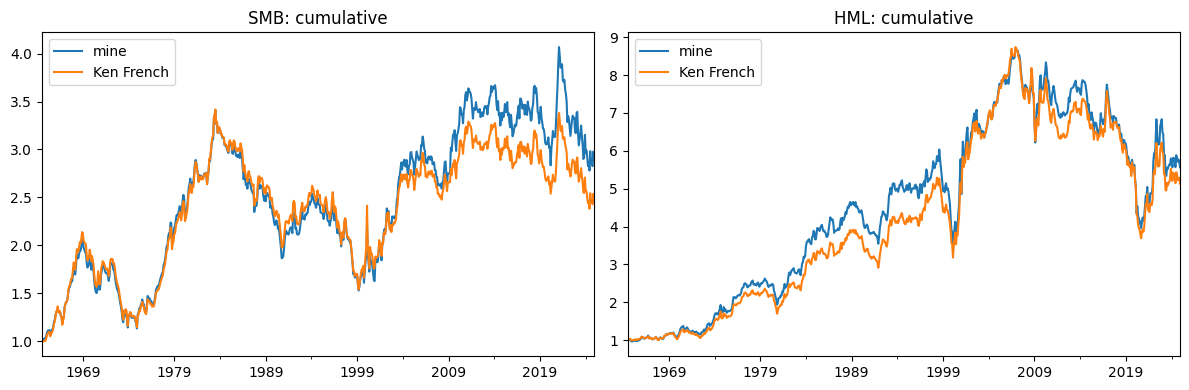

In [16]:
# Ken French reference. His values are in PERCENT -> /100.
kf = pd.read_parquet(Data / "ff3_monthly.parquet")
kf.columns = [c.strip() for c in kf.columns]
# kf index is the month; align to month-end like our factors
kf = kf.rename(columns={"SMB": "SMB_kf", "HML": "HML_kf"})
kf_m = kf[["SMB_kf", "HML_kf"]] / 100.0
kf_m.index = pd.to_datetime(kf_m.index).to_period("M")

mine = factors.copy()
mine.index = pd.to_datetime(mine.index).to_period("M")

cmp = mine.join(kf_m, how="inner").dropna()
corr_smb = cmp["SMB_me"].corr(cmp["SMB_kf"])
corr_hml = cmp["HML_me"].corr(cmp["HML_kf"])
print(f"Overlap months: {len(cmp)}")
print(f"SMB correlation vs Ken French: {corr_smb:.3f}")
print(f"HML correlation vs Ken French: {corr_hml:.3f}")

print("\nWIN CONDITION: both > 0.95")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, name in zip(ax, ["SMB", "HML"]):
    (1 + cmp[f"{name}_me"]).cumprod().plot(ax=a, label="mine")
    (1 + cmp[f"{name}_kf"]).cumprod().plot(ax=a, label="Ken French")
    a.set_title(f"{name}: cumulative")
    a.legend()
fig.tight_layout()
fig.savefig("figures/smb_hml_validation.png", dpi=120)
plt.show()


In [ ]:
# pandas groupby && Quantile